### PassGuard — ML-Based Password Strength Predictor

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)

# Models
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.naive_bayes     import GaussianNB
from xgboost                 import XGBClassifier

plt.style.use('seaborn-v0_8-whitegrid')
print('All libraries loaded successfully!')

All libraries loaded successfully!


## 2. Load Dataset

In [2]:
df = pd.read_csv('../data/passwords.csv', 
                  on_bad_lines='skip',
                  engine='python',
                  quoting=3)          
df.columns = ['password', 'strength']

# Rename columns if needed
df.columns = ['password', 'strength']

print('Shape:', df.shape)
print('\nFirst 5 rows:')
display(df.head())

print('\nData Types:')
print(df.dtypes)

print('\nMissing Values:')
print(df.isnull().sum())

print('\nStrength Distribution:')
print(df['strength'].value_counts())
print('\n0 = Weak  |  1 = Medium  |  2 = Strong')

Shape: (669640, 2)

First 5 rows:


,password,strength
0,kzde5577,1
1,kino3434,1
2,visi7k1yr,1
3,megzy123,1
4,lamborghin1,1



Data Types:
password      str
strength    int64
dtype: object

Missing Values:
password    1
strength    0
dtype: int64

Strength Distribution:
strength
1    496801
0     89702
2     83137
Name: count, dtype: int64

0 = Weak  |  1 = Medium  |  2 = Strong


## 3. Exploratory Data Analysis (EDA)

In [3]:
# Drop nulls and reset index
df.dropna(inplace=True)
df['password'] = df['password'].astype(str)
df.reset_index(drop=True, inplace=True)
print('After cleaning — Shape:', df.shape)

After cleaning — Shape: (669639, 2)


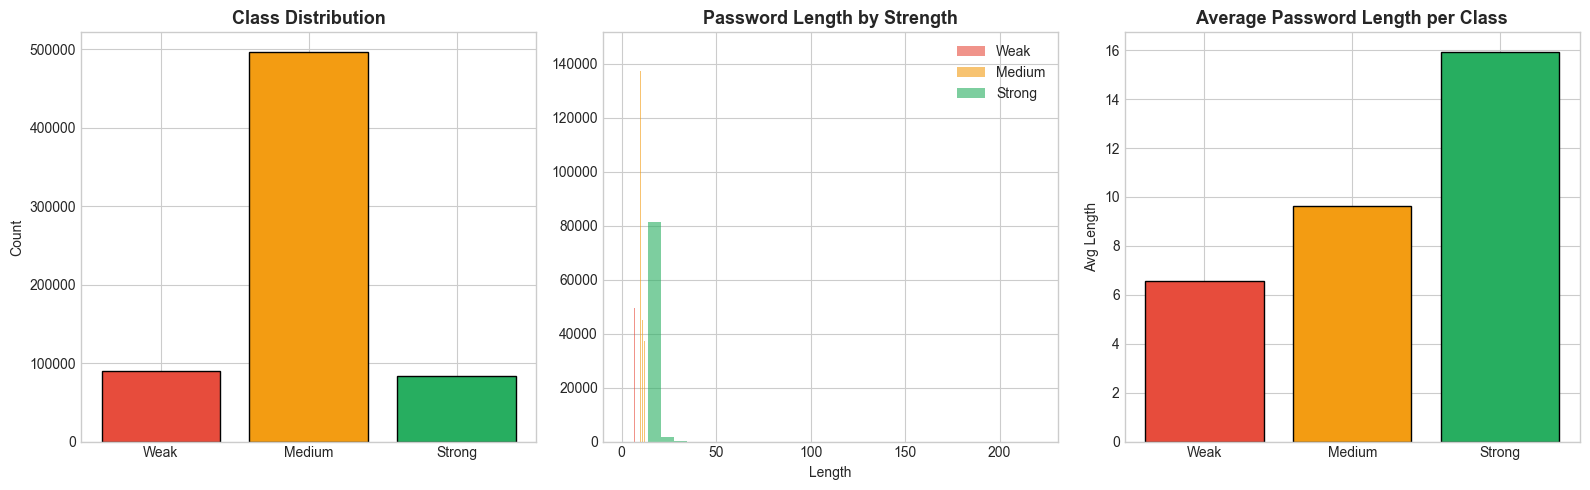

EDA plots saved.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Class Distribution
label_map = {0: 'Weak', 1: 'Medium', 2: 'Strong'}
counts = df['strength'].value_counts().sort_index()
axes[0].bar([label_map[i] for i in counts.index], counts.values,
            color=['#e74c3c', '#f39c12', '#27ae60'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

# Password Length Distribution
df['length'] = df['password'].apply(len)
for label, color in zip([0,1,2], ['#e74c3c','#f39c12','#27ae60']):
    axes[1].hist(df[df['strength']==label]['length'],
                 bins=30, alpha=0.6, label=label_map[label], color=color)
axes[1].set_title('Password Length by Strength', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Length')
axes[1].legend()

# Average length per class
avg_len = df.groupby('strength')['length'].mean()
axes[2].bar([label_map[i] for i in avg_len.index], avg_len.values,
            color=['#e74c3c','#f39c12','#27ae60'], edgecolor='black')
axes[2].set_title('Average Password Length per Class', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Avg Length')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()
print('EDA plots saved.')

## 4. Feature Engineering

In [5]:
def extract_features(password):
    p = str(password)
    length = len(p)
    num_upper   = sum(1 for c in p if c.isupper())
    num_lower   = sum(1 for c in p if c.islower())
    num_digits  = sum(1 for c in p if c.isdigit())
    num_special = sum(1 for c in p if not c.isalnum())
    unique_chars = len(set(p))

    # Entropy (information theory)
    from collections import Counter
    freq = Counter(p)
    entropy = -sum((v/length) * np.log2(v/length) for v in freq.values()) if length > 0 else 0

    return {
        'length':              length,
        'num_upper':           num_upper,
        'num_lower':           num_lower,
        'num_digits':          num_digits,
        'num_special':         num_special,
        'has_upper':           int(num_upper > 0),
        'has_lower':           int(num_lower > 0),
        'has_digit':           int(num_digits > 0),
        'has_special':         int(num_special > 0),
        'unique_chars':        unique_chars,
        'char_variety_ratio':  unique_chars / max(length, 1),
        'entropy':             round(entropy, 4),
        'starts_with_cap':     int(p[0].isupper() if p else 0),
        'ends_with_digit':     int(p[-1].isdigit() if p else 0),
        'sequential_nums':     int(bool(re.search(r'(012|123|234|345|456|567|678|789)', p))),
        'repeated_chars':      int(bool(re.search(r'(.)\1\1', p))),
        'common_weak_pattern': int(bool(re.search(
            r'(password|qwerty|abc|111|000|admin|login|welcome|pakistan|lahore|imran|iloveyou)',
            p.lower()))),
        'only_letters':        int(p.isalpha()),
        'only_digits':         int(p.isdigit()),
        'digit_ratio':         num_digits / max(length, 1),
        'special_ratio':       num_special / max(length, 1),
    }

print('Extracting features from', len(df), 'passwords...')
feature_df = pd.DataFrame([extract_features(p) for p in df['password']])
print('Feature extraction complete!')
print('Features shape:', feature_df.shape)
display(feature_df.head())

Extracting features from 669639 passwords...
Feature extraction complete!
Features shape: (669639, 21)


,length,num_upper,num_lower,num_digits,num_special,has_upper,has_lower,has_digit,has_special,unique_chars,...,entropy,starts_with_cap,ends_with_digit,sequential_nums,repeated_chars,common_weak_pattern,only_letters,only_digits,digit_ratio,special_ratio
0,8,0,4,4,0,0,1,1,0,6,...,2.5000,0,1,0,0,0,0,0,0.500000,0.0
1,8,0,4,4,0,0,1,1,0,6,...,2.5000,0,1,0,0,0,0,0,0.500000,0.0
2,9,0,7,2,0,0,1,1,0,8,...,2.9477,0,0,0,0,0,0,0,0.222222,0.0
3,8,0,5,3,0,0,1,1,0,8,...,3.0000,0,1,1,0,0,0,0,0.375000,0.0
4,11,0,10,1,0,0,1,1,0,11,...,3.4594,0,1,0,0,0,0,0,0.090909,0.0


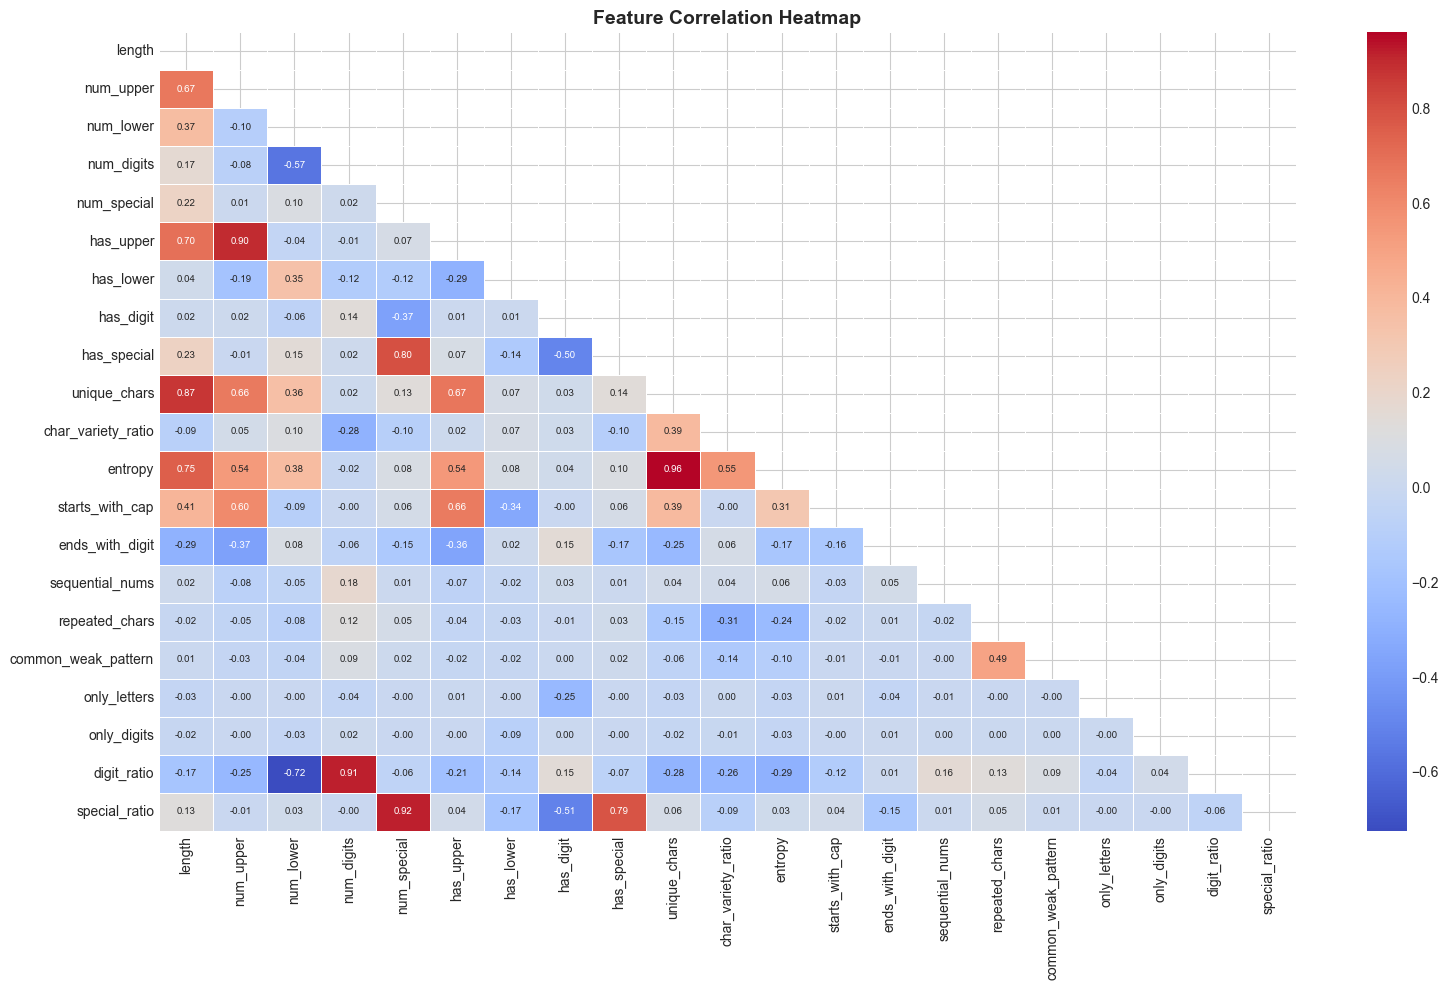

In [6]:
# Feature Correlation Heatmap
plt.figure(figsize=(16, 10))
corr = feature_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

## 5. Preprocessing — Train/Test Split & Scaling

In [7]:
X = feature_df.copy()
y = df['strength']

# 80/20 split — stratified to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit scaler on TRAIN only to avoid data leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size : {len(X_train):,}')
print(f'Test size  : {len(X_test):,}')
print(f'\nClass balance in train:')
print(y_train.value_counts())

Train size : 535,711
Test size  : 133,928

Class balance in train:
strength
1    397441
0     71761
2     66509
Name: count, dtype: int64


## 6. Train & Compare All Models (Baseline)

In [8]:
models = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':          DecisionTreeClassifier(random_state=42),
    'Random Forest':          RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':      GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Extra Trees':            ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':                XGBClassifier(n_estimators=100, random_state=42,
                                            use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1),
    'KNN':                    KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes':            GaussianNB(),
}

results = {}
print(f'{"Model":<28} {"Train Acc":>10} {"Test Acc":>10}')
print('-' * 52)

for name, model in models.items():
    # Use scaled data for models that need it
    if name in ['Logistic Regression', 'SVM', 'KNN']:
        model.fit(X_train_sc, y_train)
        train_acc = accuracy_score(y_train, model.predict(X_train_sc))
        test_acc  = accuracy_score(y_test,  model.predict(X_test_sc))
    else:
        model.fit(X_train, y_train)
        train_acc = accuracy_score(y_train, model.predict(X_train))
        test_acc  = accuracy_score(y_test,  model.predict(X_test))

    results[name] = {'train': train_acc, 'test': test_acc, 'model': model}
    print(f'{name:<28} {train_acc*100:>9.2f}%  {test_acc*100:>9.2f}%')

Model                         Train Acc   Test Acc
----------------------------------------------------
Logistic Regression              99.99%      99.99%
Decision Tree                   100.00%     100.00%
Random Forest                   100.00%     100.00%
Gradient Boosting               100.00%     100.00%
Extra Trees                     100.00%      99.99%
XGBoost                         100.00%     100.00%
KNN                              99.97%      99.95%
Naive Bayes                      88.91%      88.96%


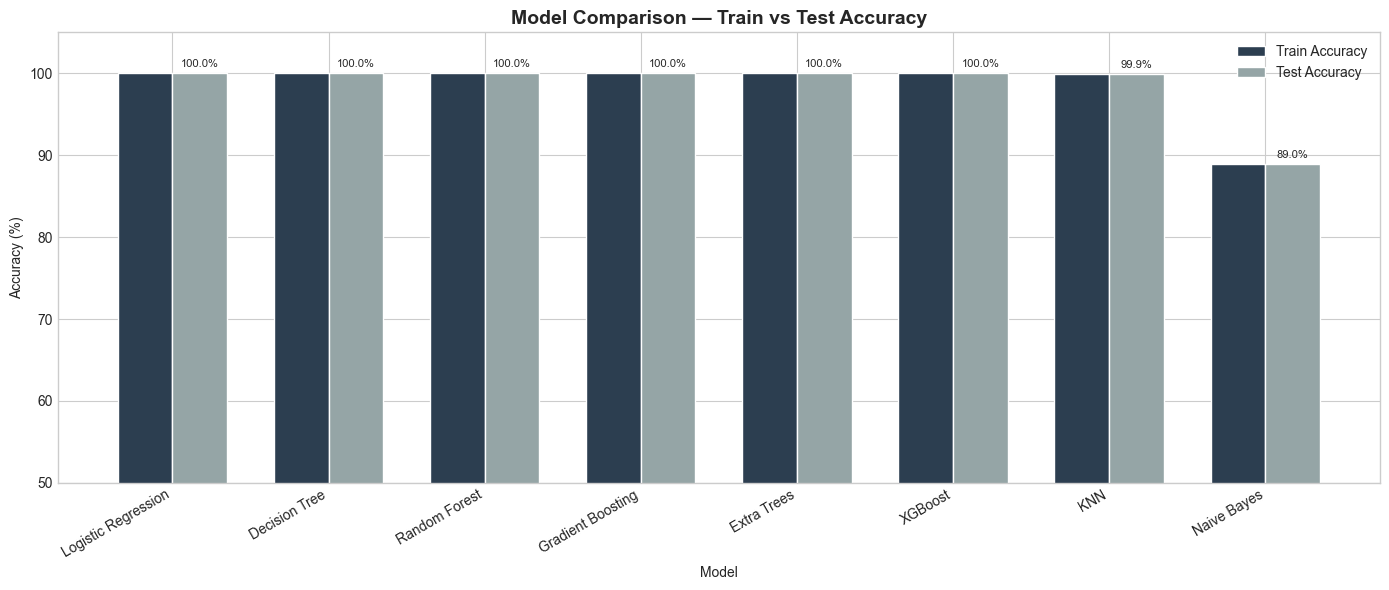

In [9]:
# Model Comparison Bar Chart
names  = list(results.keys())
train_accs = [results[n]['train']*100 for n in names]
test_accs  = [results[n]['test']*100  for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, train_accs, width, label='Train Accuracy', color='#2c3e50', edgecolor='white')
bars2 = ax.bar(x + width/2, test_accs,  width, label='Test Accuracy',  color='#95a5a6', edgecolor='white')

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Comparison — Train vs Test Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha='right')
ax.legend()
ax.set_ylim(50, 105)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## 7. Cross-Validation — Top 3 Models

5-Fold Cross Validation Results:
Model                      Mean CV Acc    Std Dev
--------------------------------------------------
Random Forest                  100.00%       0.00%
XGBoost                        100.00%       0.00%
Gradient Boosting              100.00%       0.00%


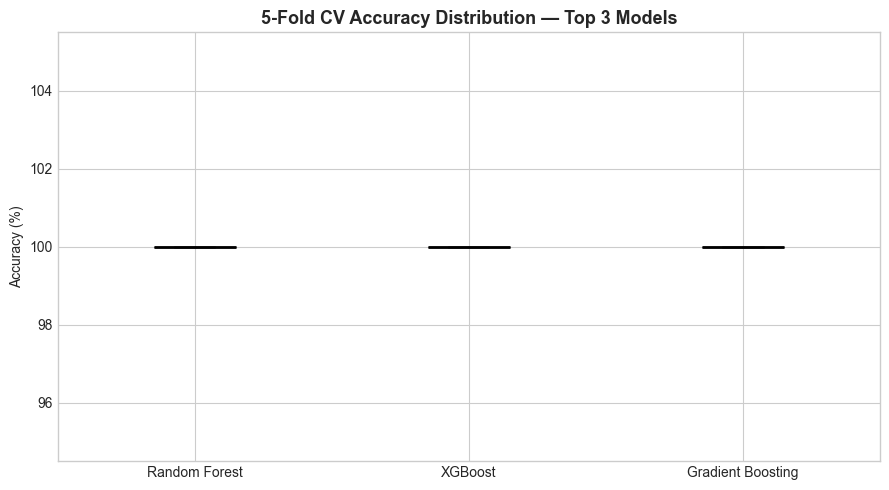

In [10]:
top3 = ['Random Forest', 'XGBoost', 'Gradient Boosting']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
print('5-Fold Cross Validation Results:')
print(f'{"Model":<25} {"Mean CV Acc":>12} {"Std Dev":>10}')
print('-' * 50)

for name in top3:
    model = results[name]['model']
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                             scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<25} {scores.mean()*100:>11.2f}%  {scores.std()*100:>9.2f}%')

# Box plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot([cv_results[n]*100 for n in top3], labels=top3, patch_artist=True,
           boxprops=dict(facecolor='#bdc3c7', color='black'),
           medianprops=dict(color='black', linewidth=2))
ax.set_title('5-Fold CV Accuracy Distribution — Top 3 Models', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
plt.tight_layout()
plt.savefig('cv_boxplot.png', dpi=150)
plt.show()

## 8. Hyperparameter Tuning — GridSearchCV (Random Forest)

In [11]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth':    [10, 15, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    rf_base, param_grid,
    cv=3, scoring='accuracy',
    n_jobs=-1, verbose=1
)

# Use a sample for speed — remove sample for full tuning
sample_idx = X_train.sample(n=min(50000, len(X_train)), random_state=42).index
grid_search.fit(X_train.loc[sample_idx], y_train.loc[sample_idx])

print('\nBest Parameters:', grid_search.best_params_)
print('Best CV Score:   {:.4f}'.format(grid_search.best_score_))

Fitting 3 folds for each of 48 candidates, totalling 144 fits

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score:   1.0000


## 9. Final Evaluation — Best Model

In [12]:
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)   # retrain on full train set

y_pred = best_model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f'Final Test Accuracy: {acc*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred,
      target_names=['Weak', 'Medium', 'Strong']))

Final Test Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

        Weak       1.00      1.00      1.00     17940
      Medium       1.00      1.00      1.00     99360
      Strong       1.00      1.00      1.00     16628

    accuracy                           1.00    133928
   macro avg       1.00      1.00      1.00    133928
weighted avg       1.00      1.00      1.00    133928



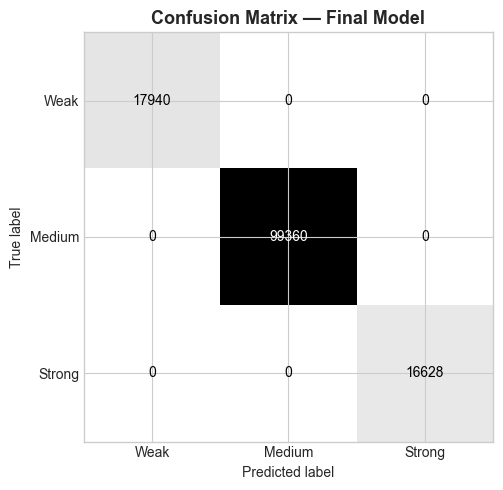

In [13]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Weak', 'Medium', 'Strong'])
disp.plot(ax=ax, cmap='Greys', colorbar=False)
ax.set_title('Confusion Matrix — Final Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

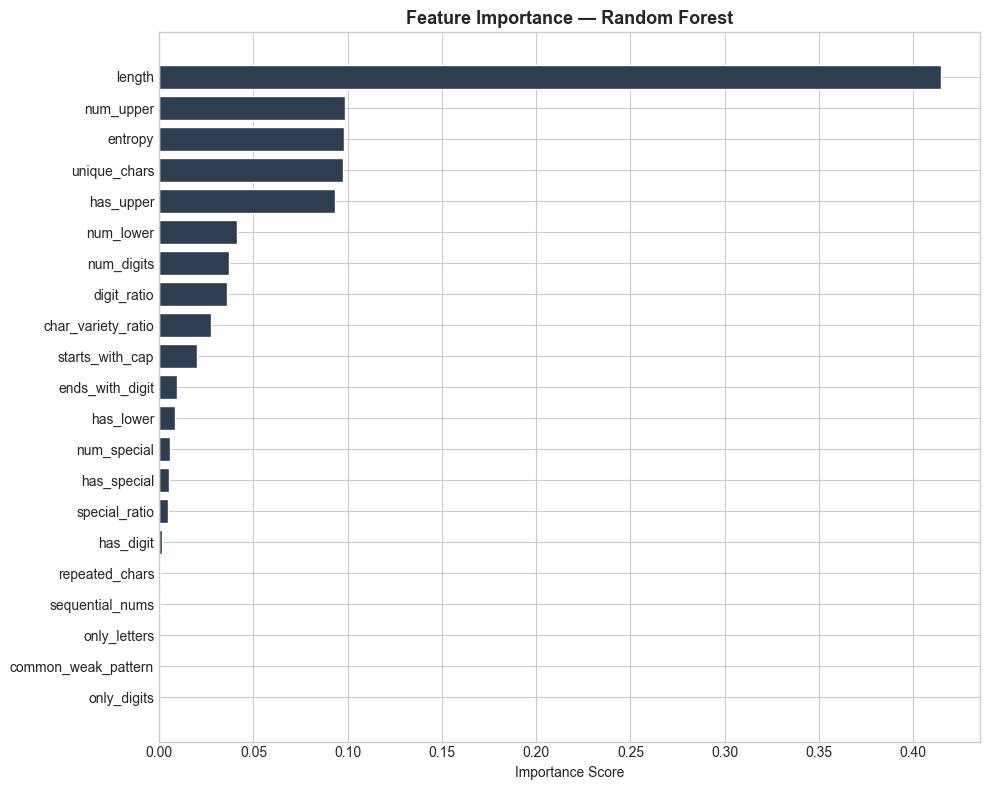

In [14]:
# Feature Importance
importances = best_model.feature_importances_
feat_names  = X_train.columns.tolist()
feat_imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_imp_df.sort_values('Importance', ascending=True, inplace=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
        color='#2c3e50', edgecolor='white')
ax.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

## 10. Save Model & Scaler with Pickle

In [15]:
with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('model.pkl  saved successfully!')
print('scaler.pkl saved successfully!')

# Quick test
with open('model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

test_pw  = 'Hajra@2024!'
test_feat = pd.DataFrame([extract_features(test_pw)])
pred      = loaded_model.predict(test_feat)[0]
label_map = {0: 'Weak', 1: 'Medium', 2: 'Strong'}
print(f'\nTest Password : "{test_pw}"')
print(f'Predicted Strength: {label_map[pred]}')

model.pkl  saved successfully!
scaler.pkl saved successfully!

Test Password : "Hajra@2024!"
Predicted Strength: Medium
